<a href="https://colab.research.google.com/github/SofiaKakou/Customer_Churn_Prediction/blob/main/notebooks/03_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Introduction

This notebook explores patterns in the cleaned telecom churn dataset. The goal is to analyze churn distribution, identify relationships between features and churn, detect potential outliers and generate insights for modelling.

# 2.Imports

In [1]:
# importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# 3.Load Dataset

In [2]:
# mounting to drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# Load cleaned dataset
path = "/content/drive/MyDrive/Thesis/Datasets/telecom_cleaned.csv"

df = pd.read_csv(path)

df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,0.692163,-0.527811,-0.335690,1.623917,1.247508,1.579670,0.484868,1.579942,-0.058619,-0.050781,...,False,False,False,False,False,False,False,False,False,False
1,0.161278,-0.527811,-0.335690,1.623917,1.320985,-0.329918,1.135375,-0.330194,-0.095916,0.147654,...,False,False,False,False,False,False,False,False,False,False
2,0.919686,-0.527811,-0.335690,-0.615795,-0.589414,1.179302,0.685024,1.179465,-1.554439,0.494917,...,False,False,False,False,False,False,False,False,False,False
3,-0.420168,-0.692467,2.978938,-0.615795,-0.589414,2.212509,-1.466653,2.212675,-2.718509,-0.596479,...,False,False,False,False,False,False,False,False,False,False
4,-0.647691,-0.527811,2.978938,-0.615795,-0.589414,-0.235822,0.634985,-0.235772,-1.022461,1.090224,...,False,False,False,False,False,False,False,False,False,False


# 4.Target Variable Exploration

In [4]:
# Churn Value Counts
df["Churn"].value_counts()

,count
Churn,
False,2278
True,388


In [5]:
# Churn Percentage Distribution
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
False,85.446362
True,14.553638


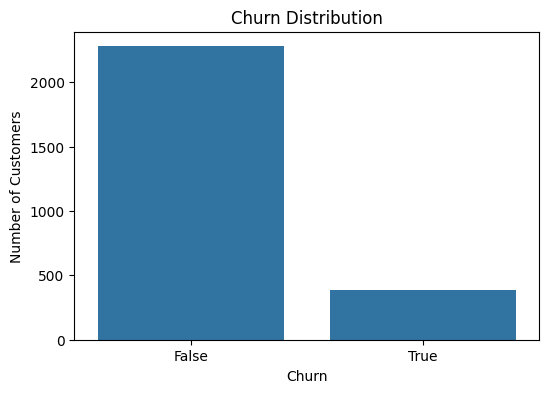

In [6]:
# Chrun Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()


## Observations

The distribution of the target variable shows that the dataset contains a higher proportion of non churn customers compared to churned ones.
This indicates a moderate class imbalance where the majority of customers remain with the service.
Class imbalance is important because it may affect model performance, particularly in prediciting the minority class (churned customers). This will be considered during model evaluation.


# 5.Numerical Feature Exploration
This section explores numerical variables using histograms and boxplots. Histograms show distributions, while botxplots help identify possible outliers.

In [7]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_columns

['Account length',
 'Area code',
 'International plan',
 'Voice mail plan',
 'Number vmail messages',
 'Total day minutes',
 'Total day calls',
 'Total day charge',
 'Total eve minutes',
 'Total eve calls',
 'Total eve charge',
 'Total night minutes',
 'Total night calls',
 'Total night charge',
 'Total intl minutes',
 'Total intl calls',
 'Total intl charge',
 'Customer service calls']

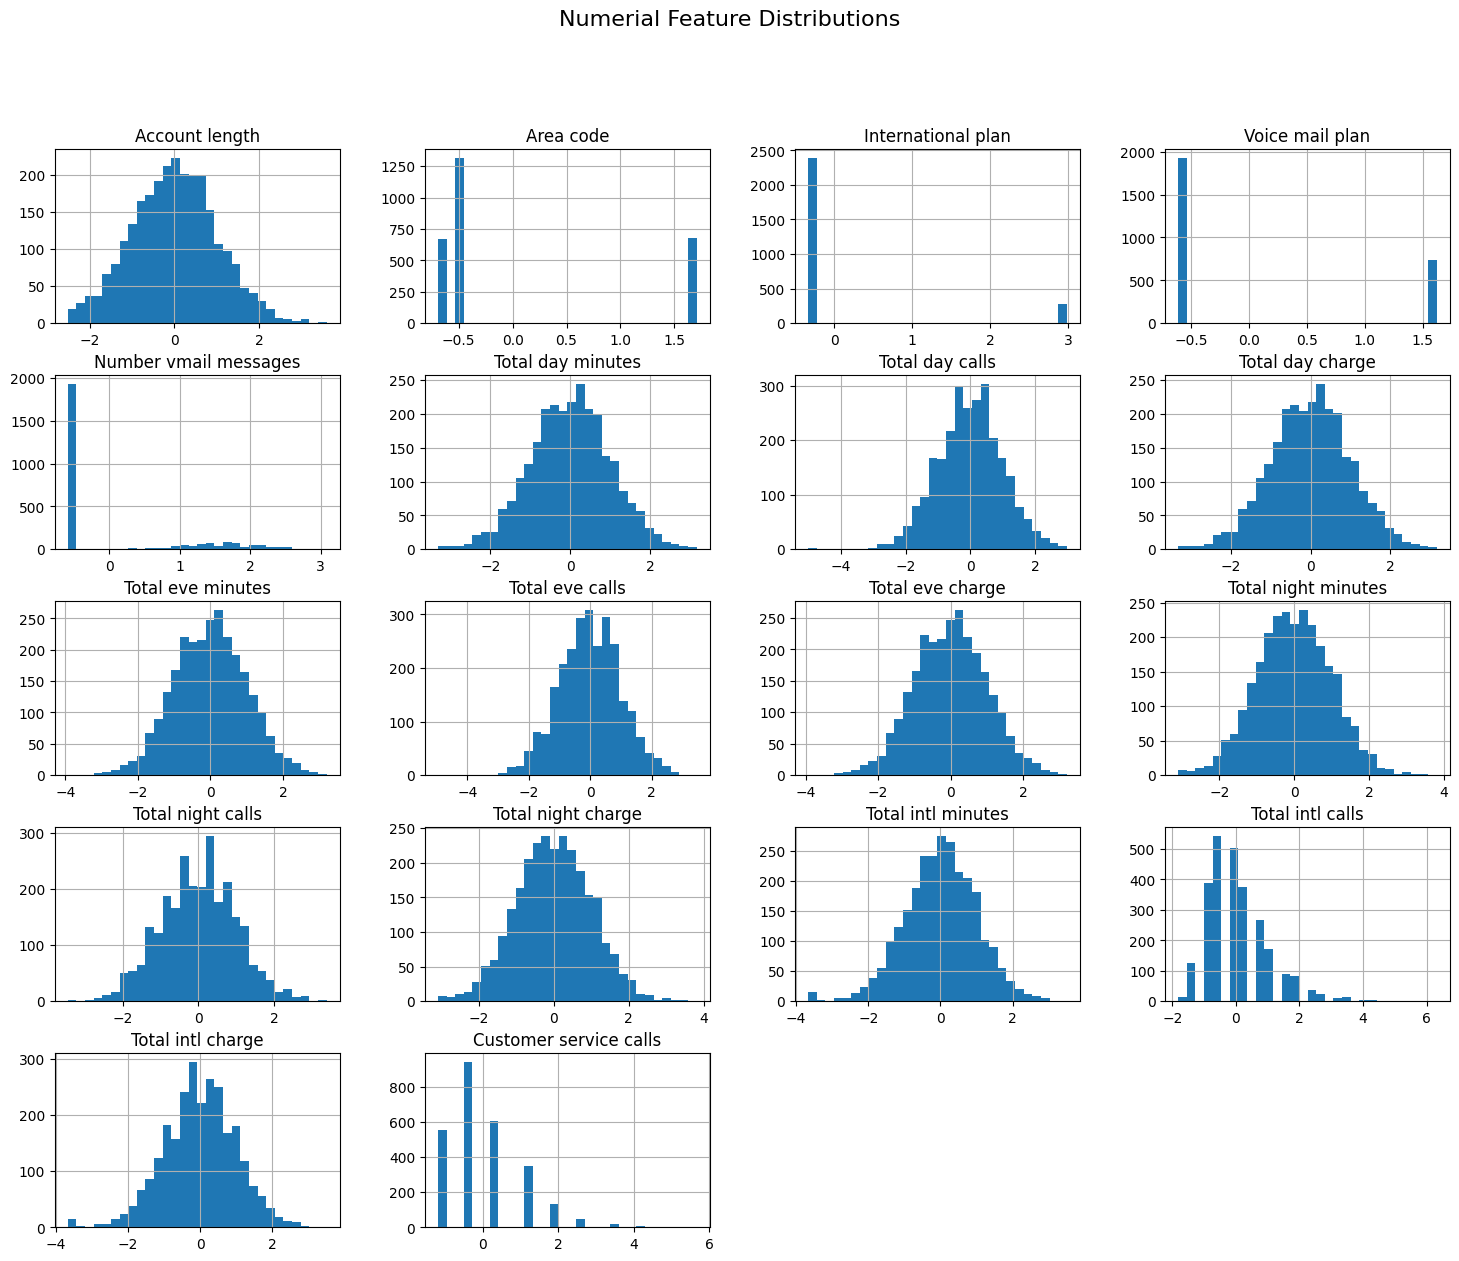

In [9]:
# Histograms for numerical features
df[numerical_columns].hist(figsize=(18, 14), bins=30)
plt.suptitle("Numerial Feature Distributions", fontsize=16)
plt.show()

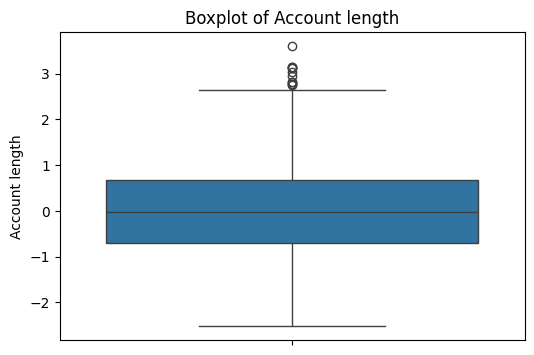

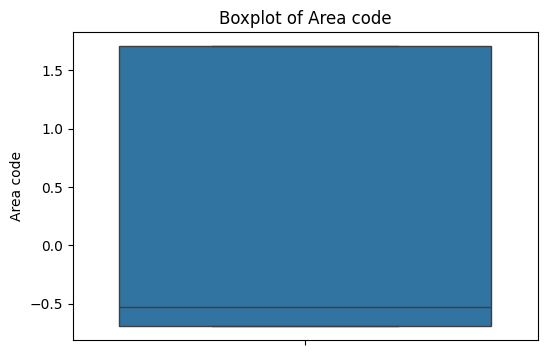

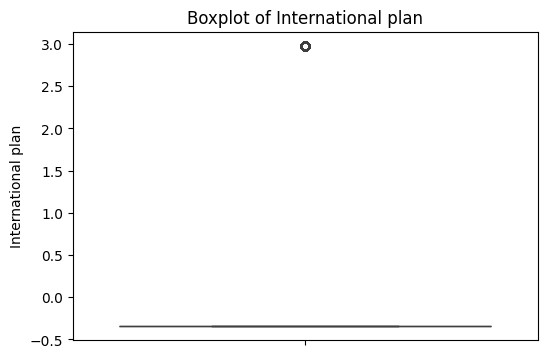

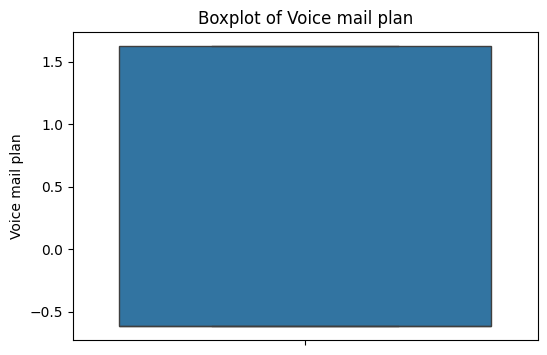

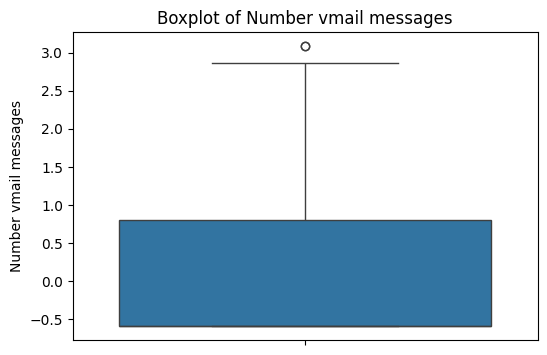

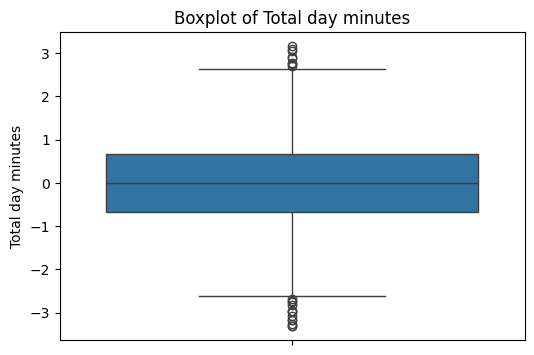

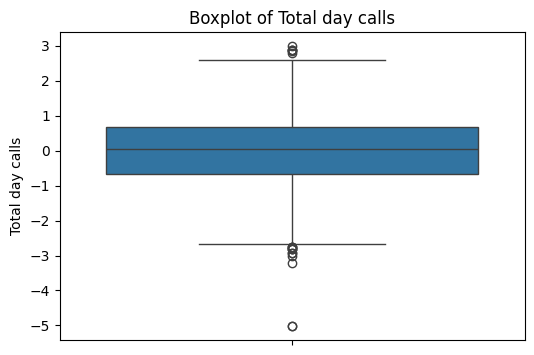

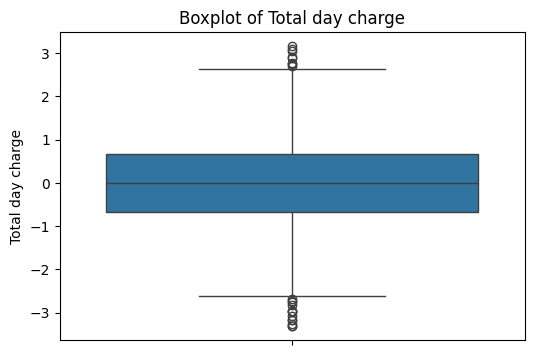

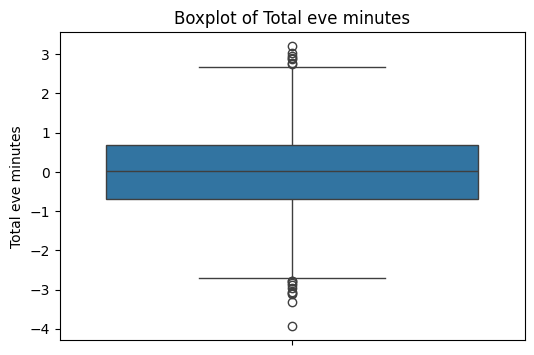

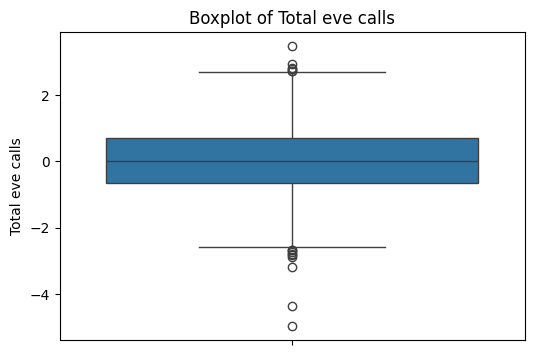

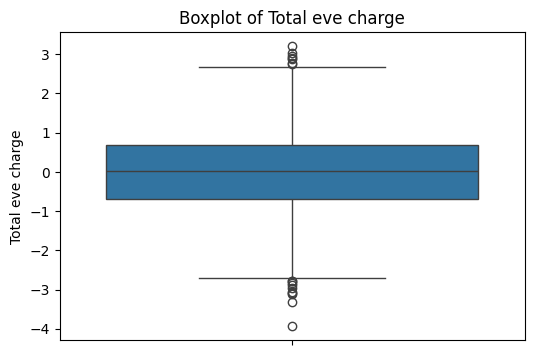

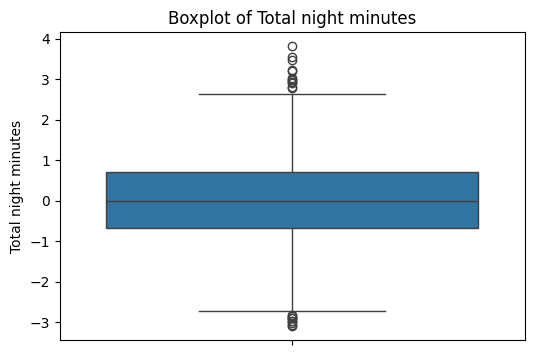

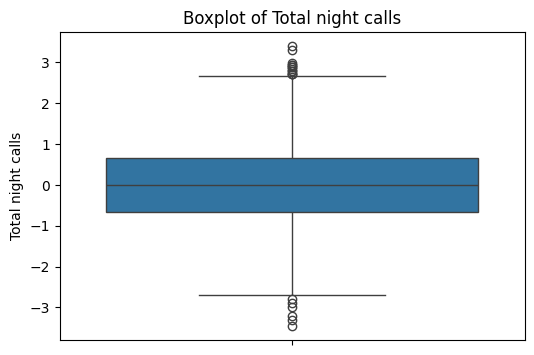

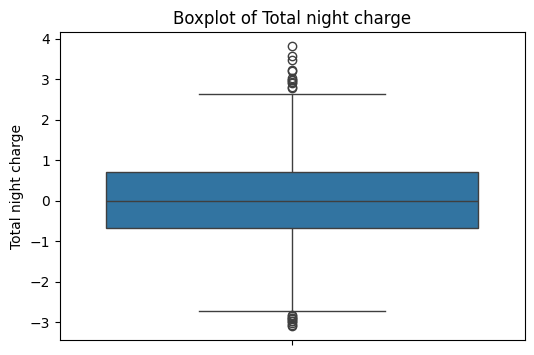

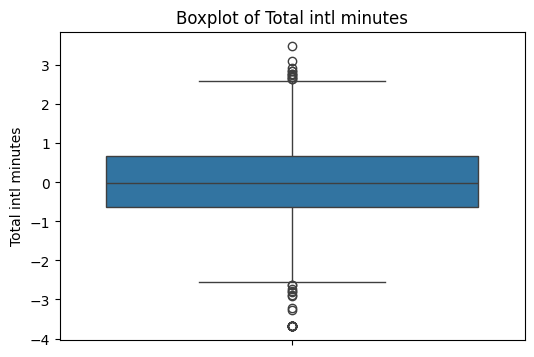

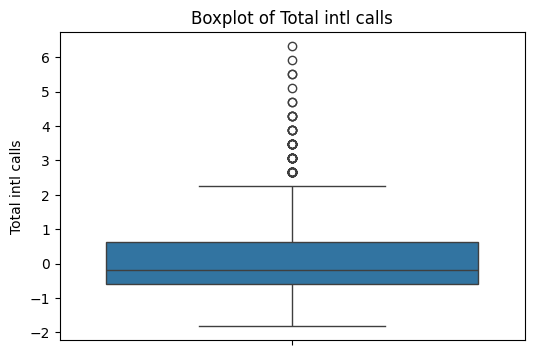

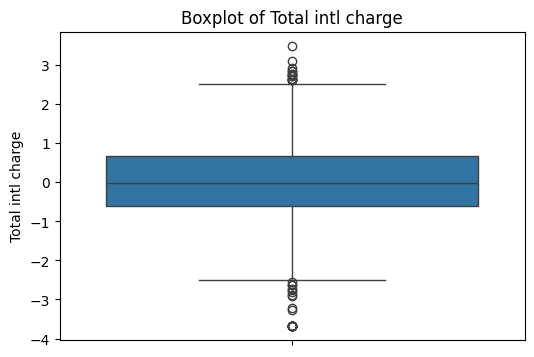

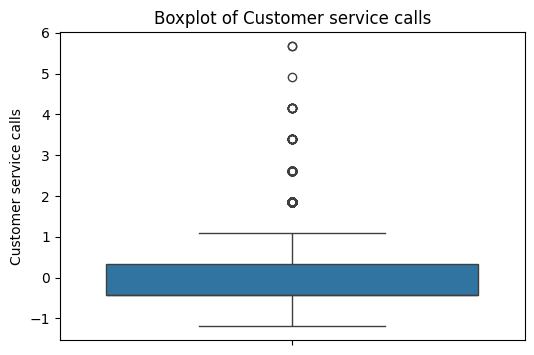

In [10]:
# Boxplots for numerical features
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

## Observations

*   Several Numerical features exhibit skewed distributions, indicating that values are not evenly distributed.
*   Boxplots reveal the presence of potential outliers in features such as call minutes and charges.
*   Some features show a wide range of values, suggesting variability in customer behaviour.
*   These outliers will not be removed at this stage but will be considered during feature engineering and modelling.






# 5.1 Numerical Features vs Churn
This section compares key numerical features against the churn target variable.

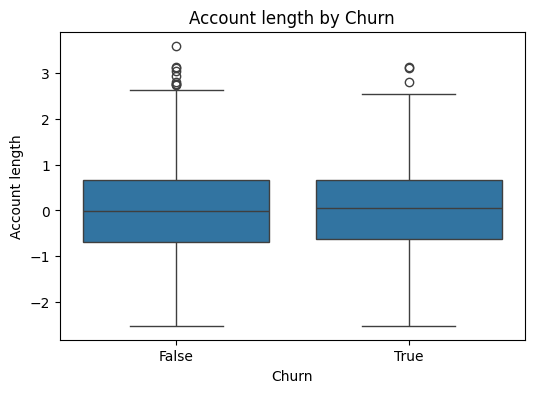

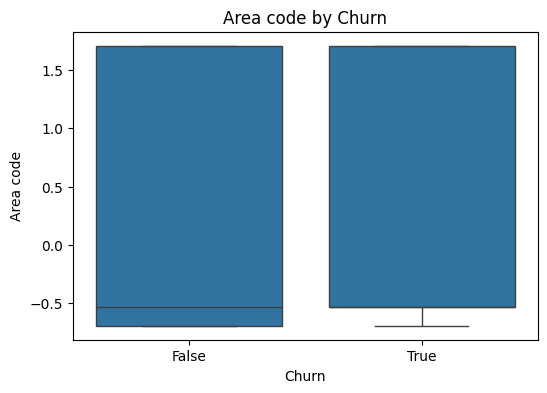

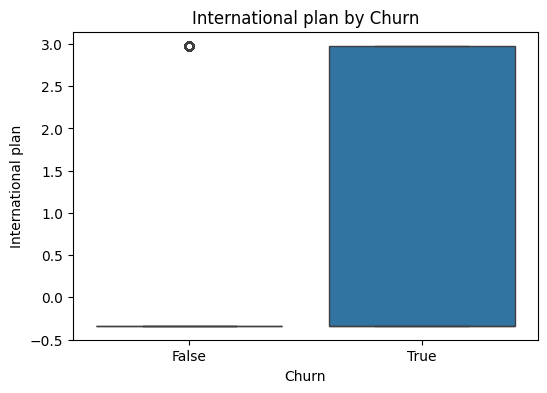

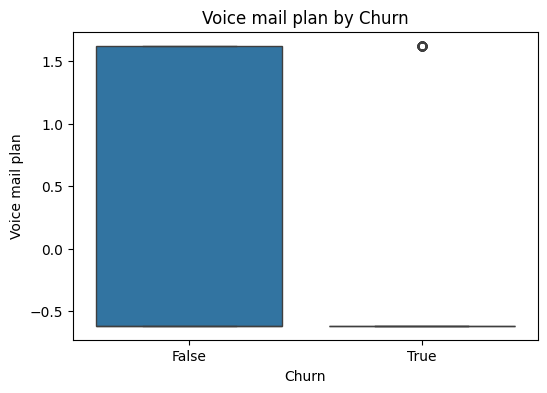

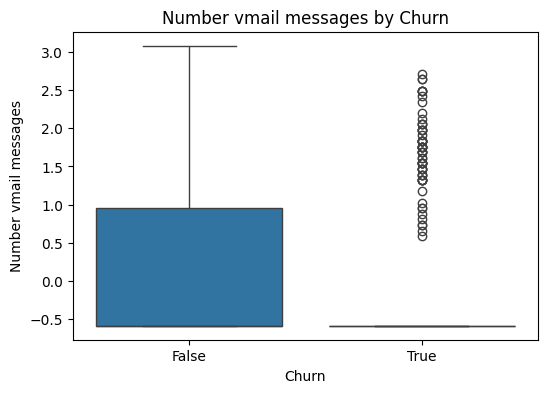

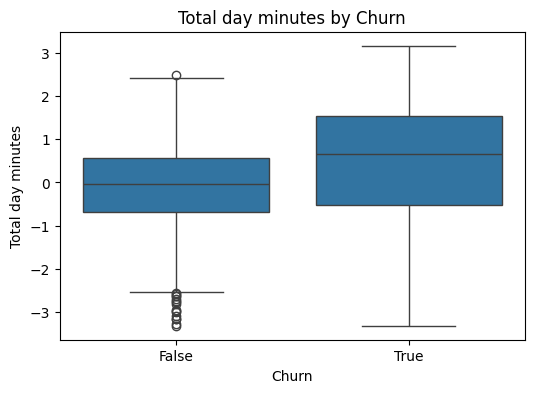

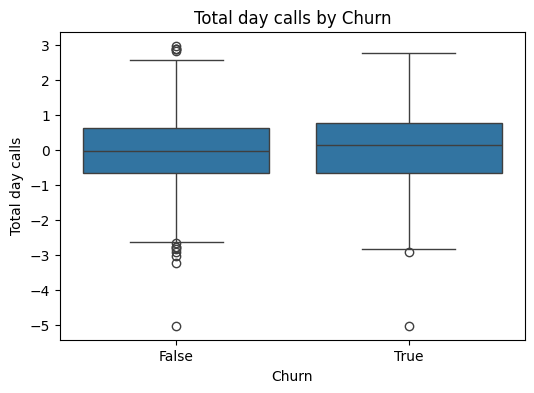

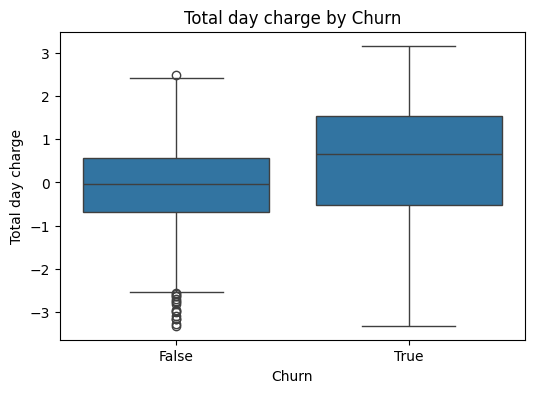

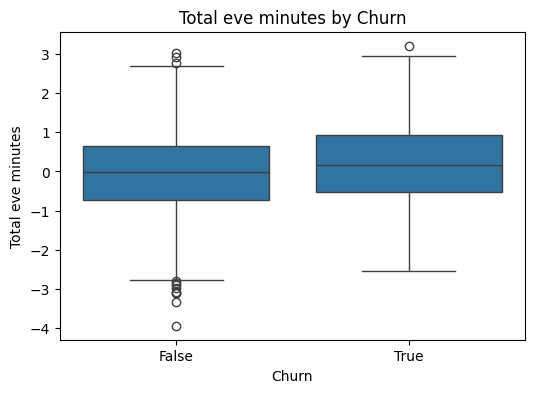

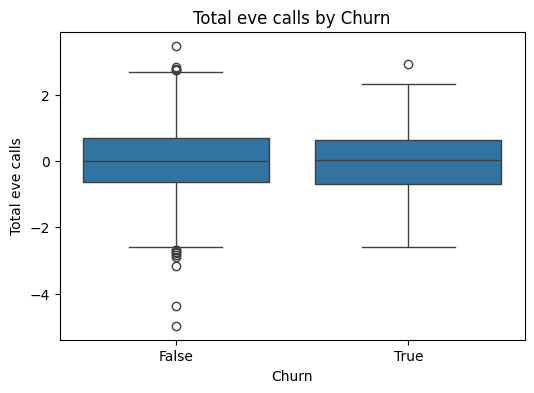

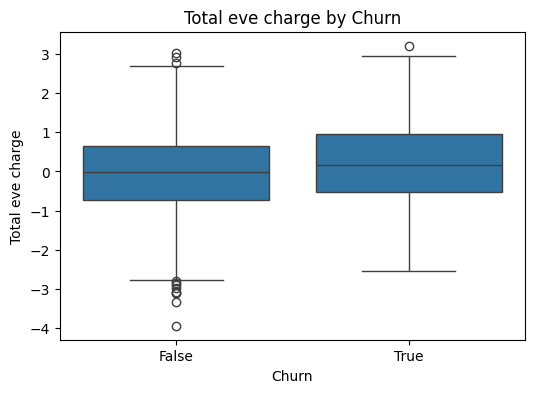

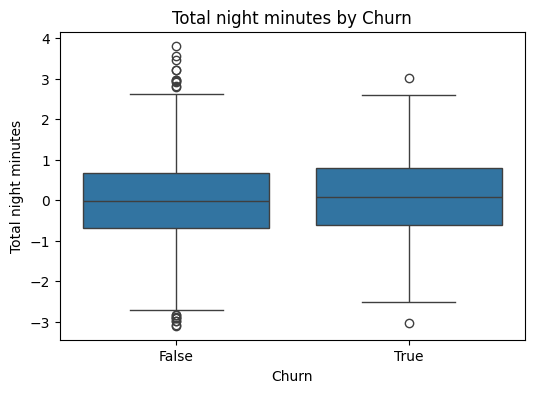

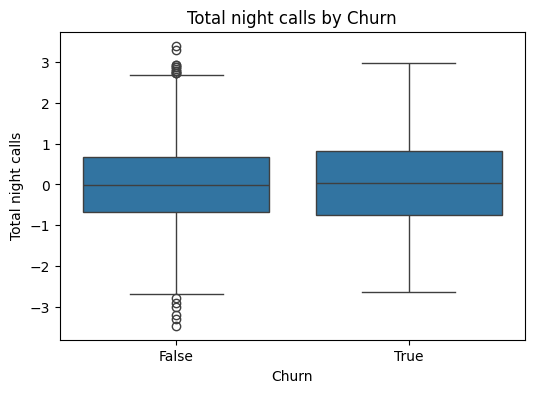

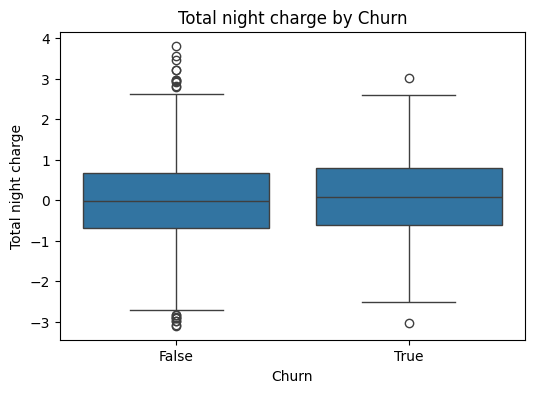

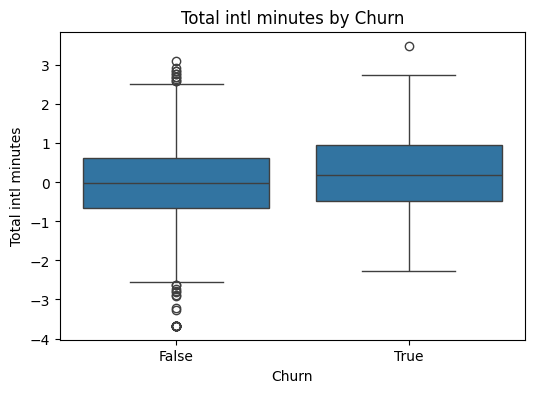

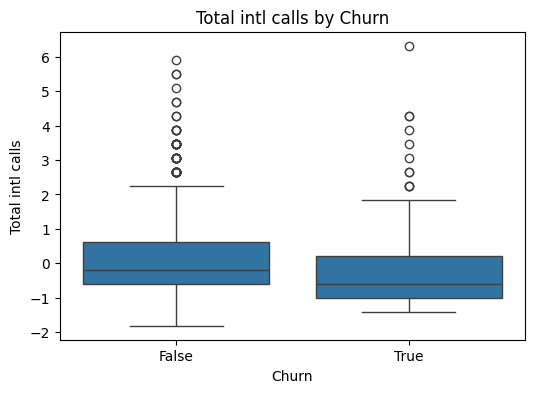

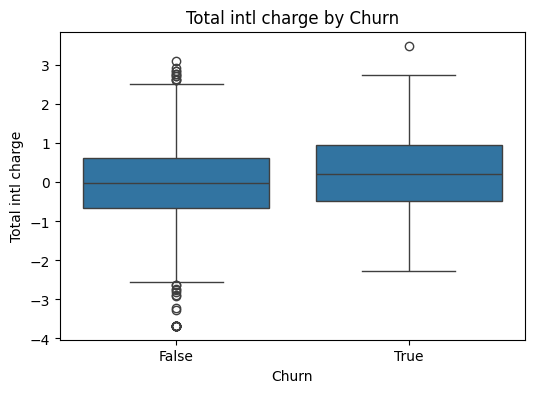

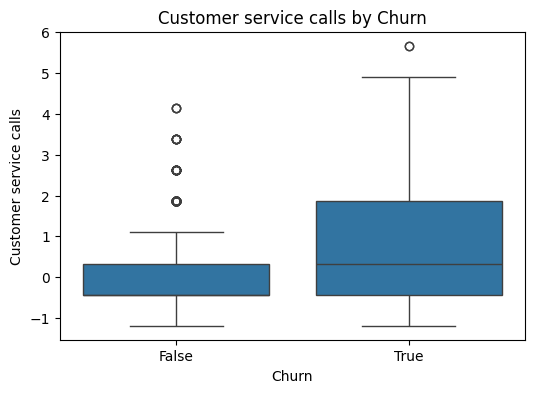

In [11]:
# Boxplots for Numerical Features by Churn
for col in numerical_columns:
  if col != "Churn":
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} by Churn")
    plt.ylabel(col)
    plt.show()

## Observations
*   Customers who churn tend to show different patterns in usage related features compared to non churn customers
*   Higher values in certain usage features appear to be associated with increased churn
*   Customer service interaction features show noticeable differences between churned and non churned groups.
*   These differences suggest that certain behavioral patterns may influence customer churn.


# 6.Categorical Feature Exploration
This section checks if any categorical features remain after preprocessing. If cetgorical variables were already encoded in Notebook 02, this section may contain limited results.

In [12]:
# Identify Categorical Columns
categorical_cols = df.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

categorical_cols

['Churn',
 'State_AL',
 'State_AR',
 'State_AZ',
 'State_CA',
 'State_CO',
 'State_CT',
 'State_DC',
 'State_DE',
 'State_FL',
 'State_GA',
 'State_HI',
 'State_IA',
 'State_ID',
 'State_IL',
 'State_IN',
 'State_KS',
 'State_KY',
 'State_LA',
 'State_MA',
 'State_MD',
 'State_ME',
 'State_MI',
 'State_MN',
 'State_MO',
 'State_MS',
 'State_MT',
 'State_NC',
 'State_ND',
 'State_NE',
 'State_NH',
 'State_NJ',
 'State_NM',
 'State_NV',
 'State_NY',
 'State_OH',
 'State_OK',
 'State_OR',
 'State_PA',
 'State_RI',
 'State_SC',
 'State_SD',
 'State_TN',
 'State_TX',
 'State_UT',
 'State_VA',
 'State_VT',
 'State_WA',
 'State_WI',
 'State_WV',
 'State_WY']

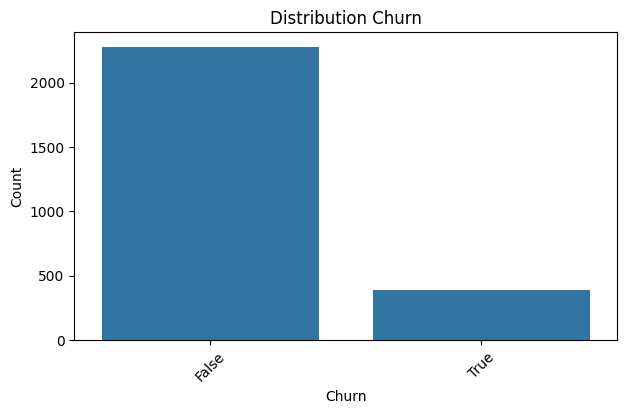

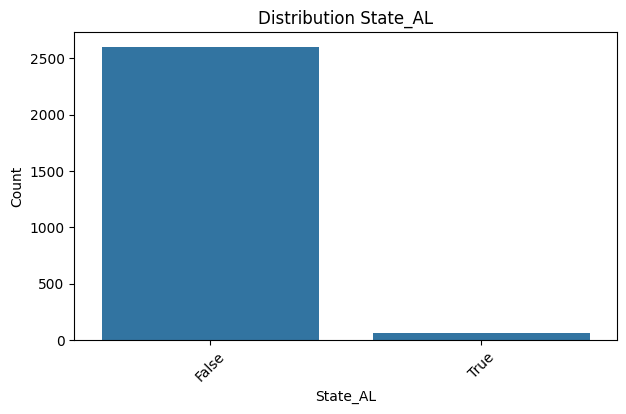

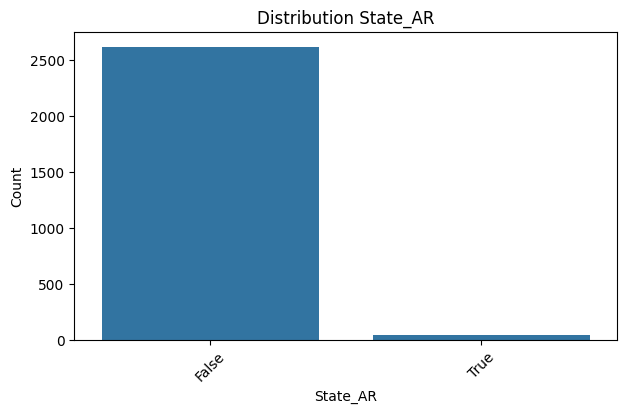

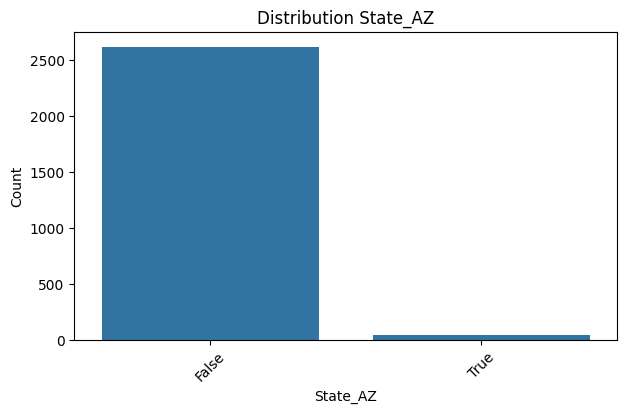

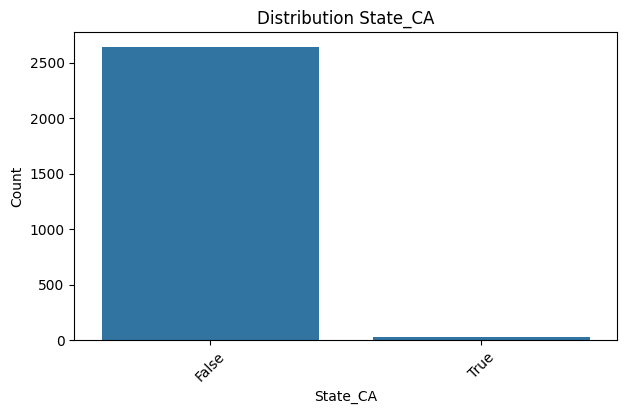

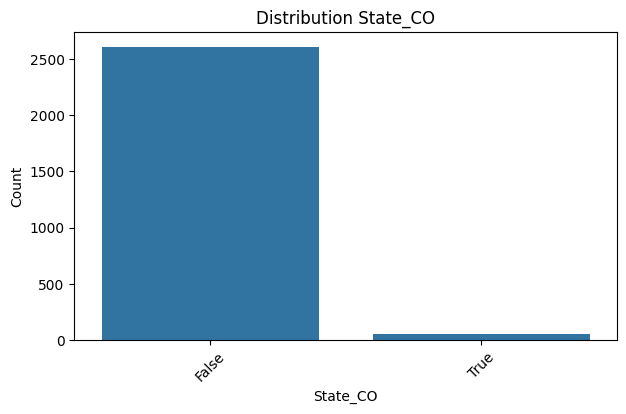

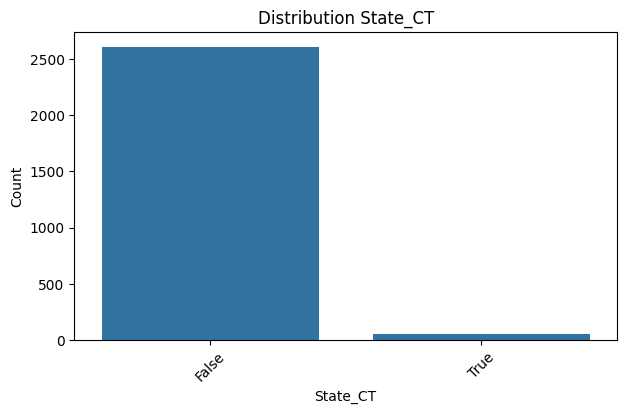

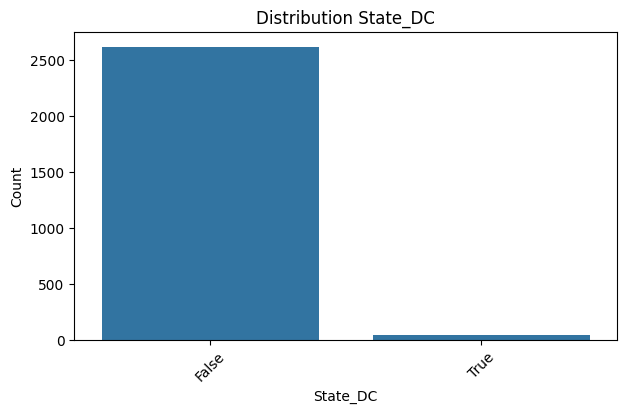

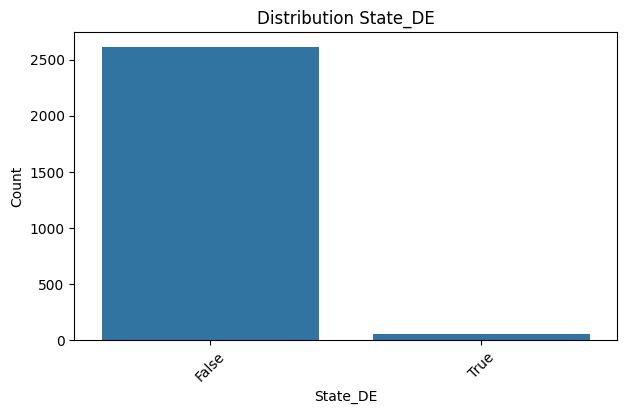

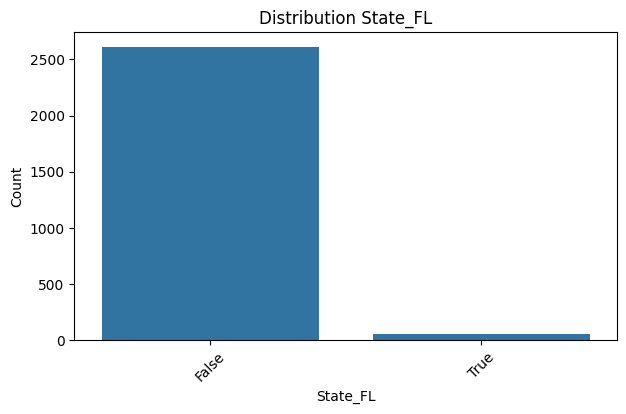

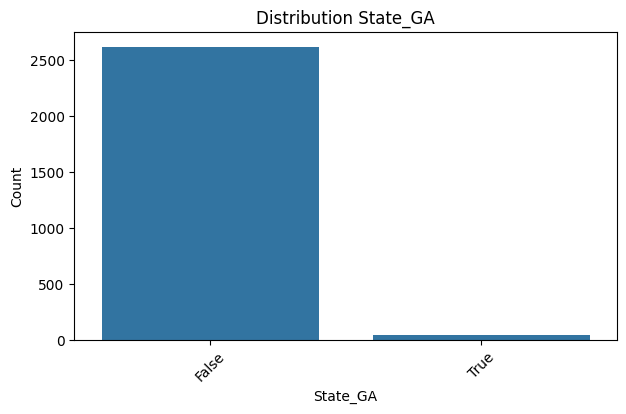

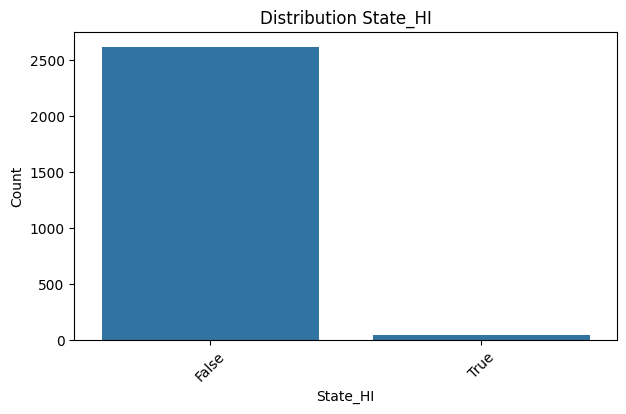

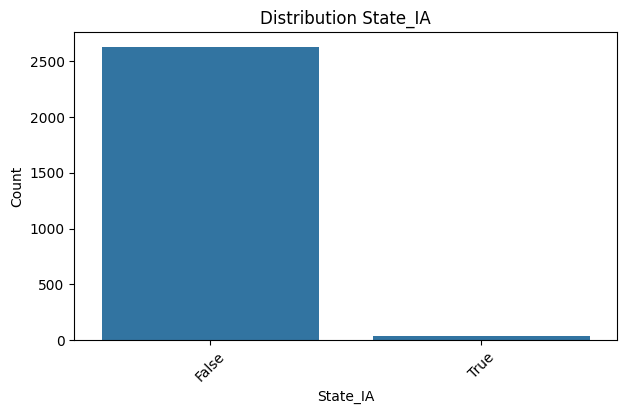

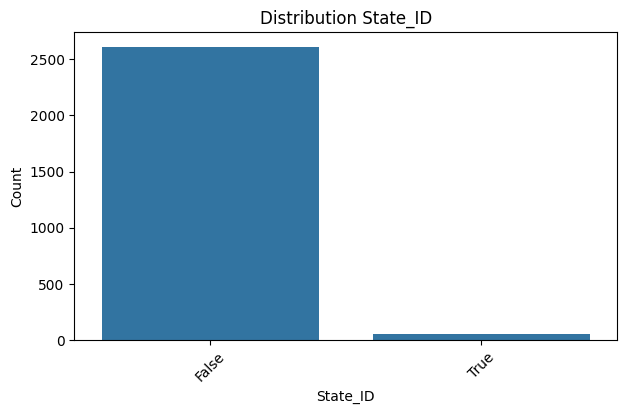

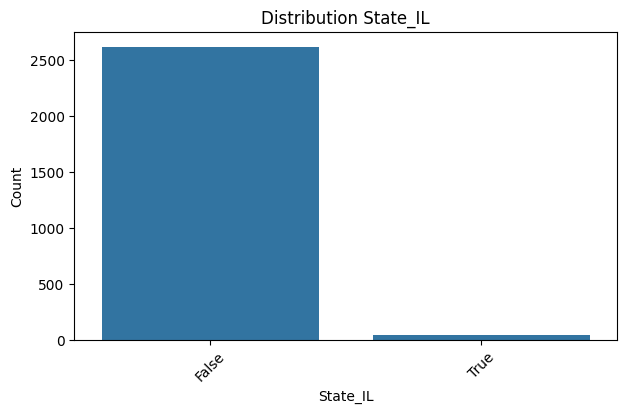

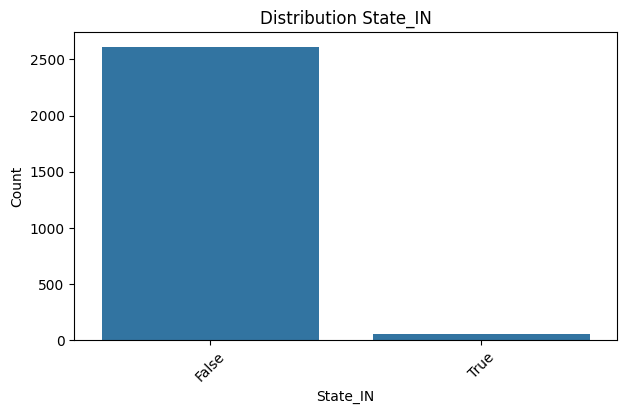

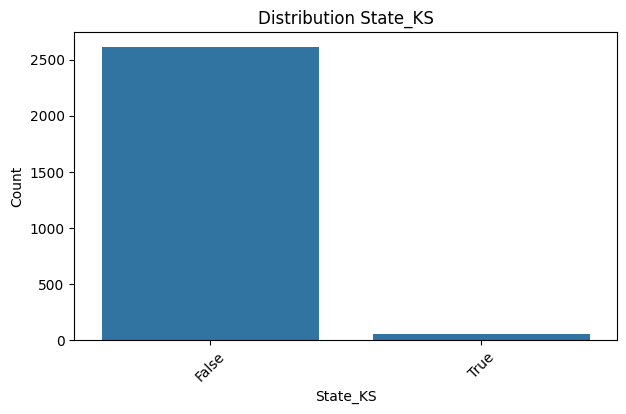

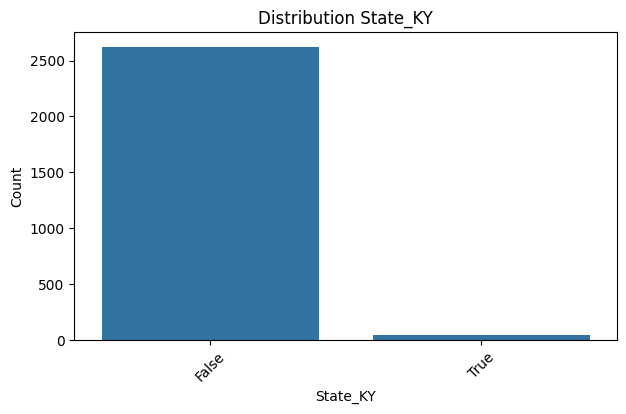

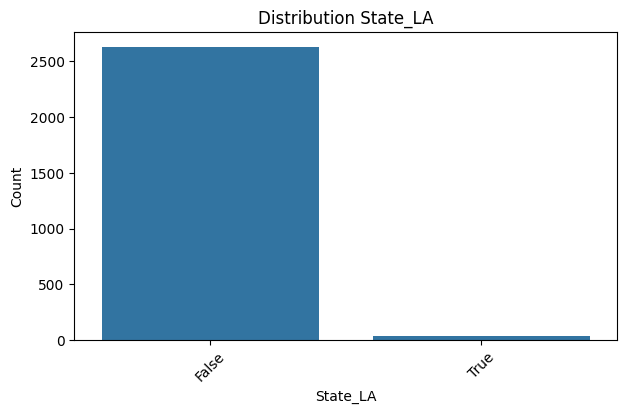

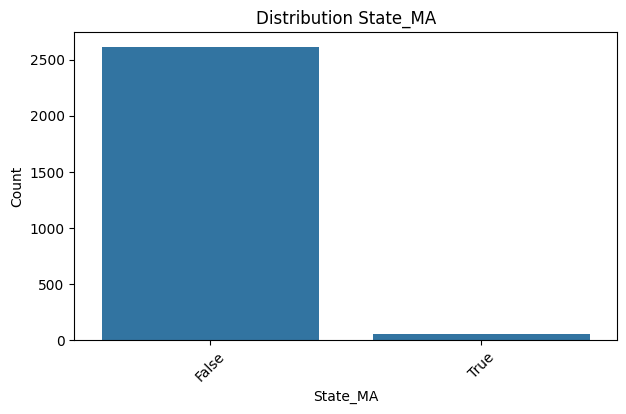

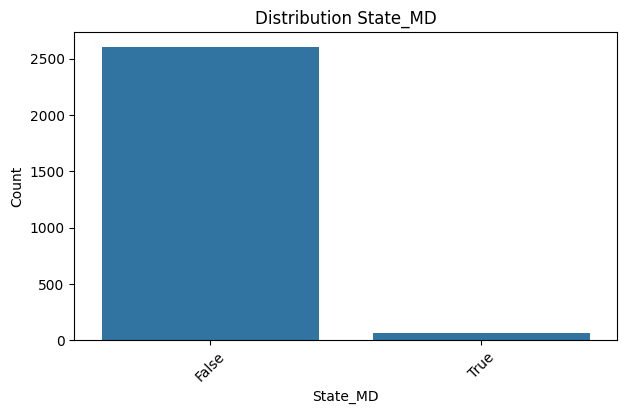

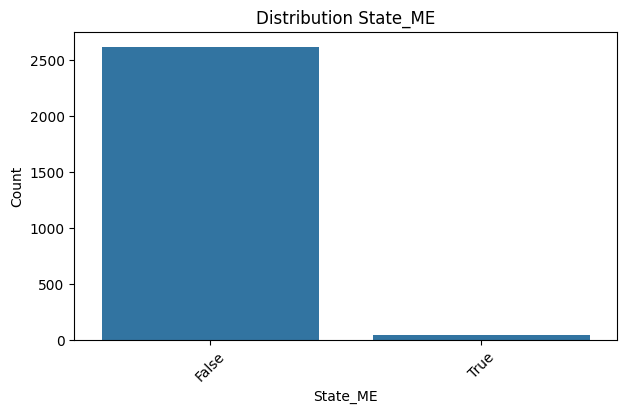

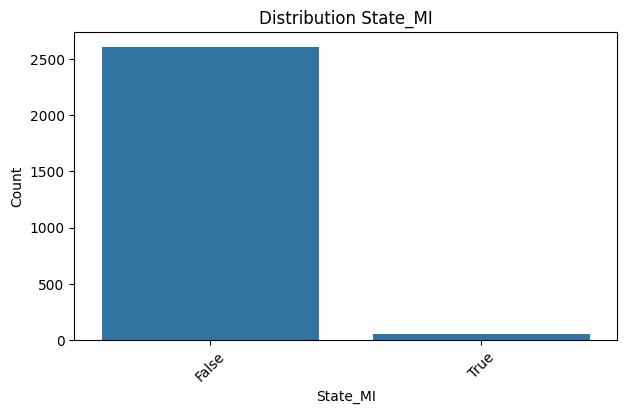

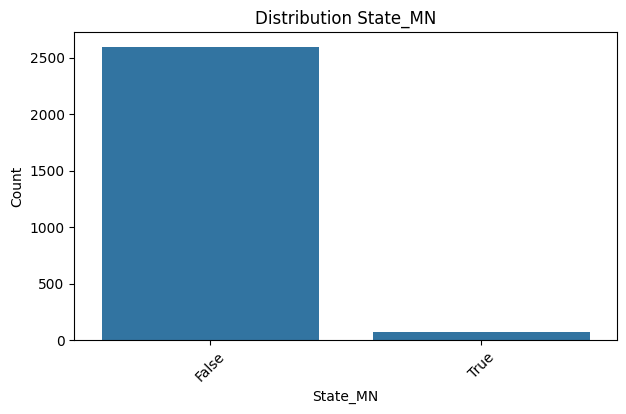

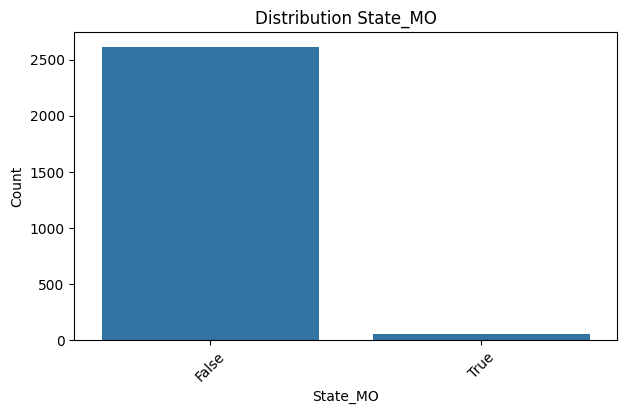

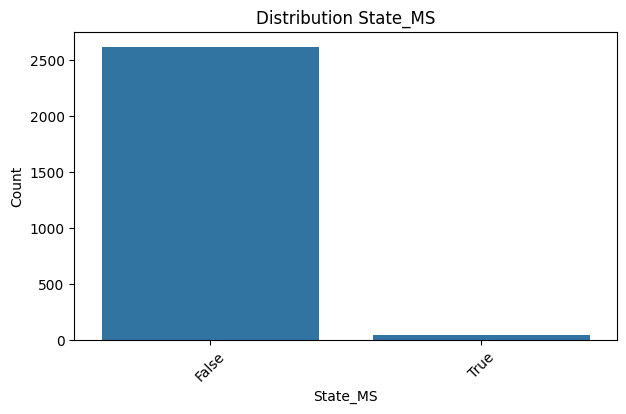

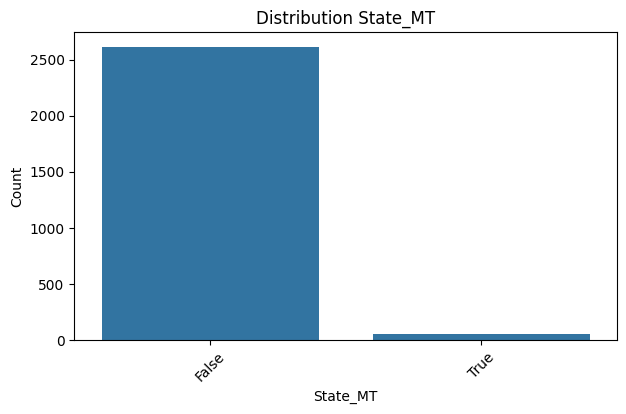

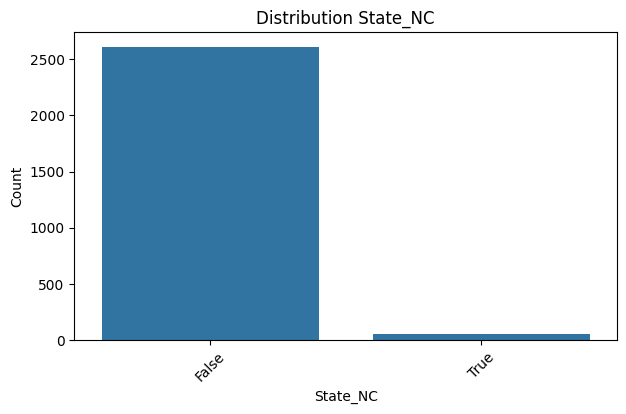

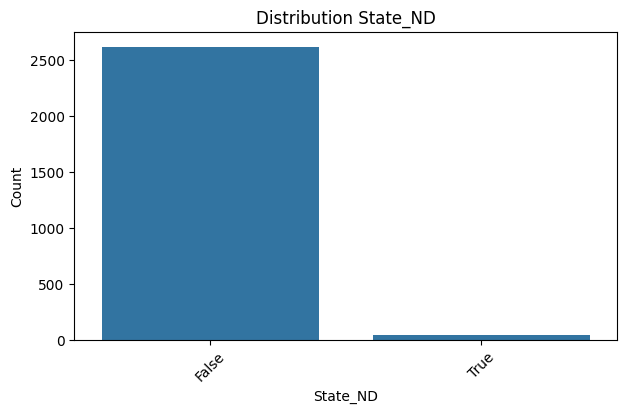

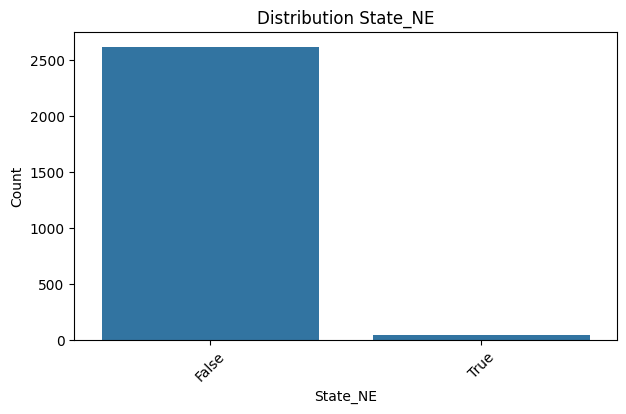

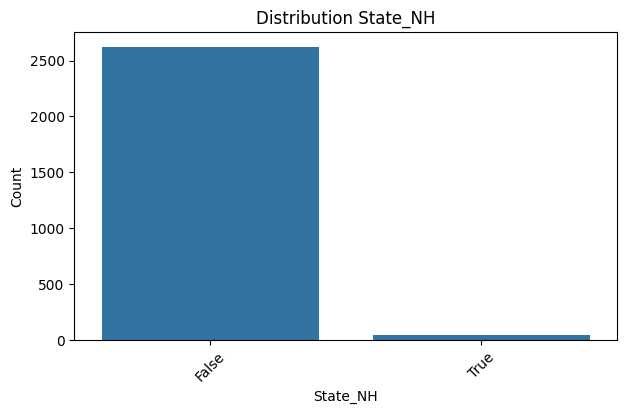

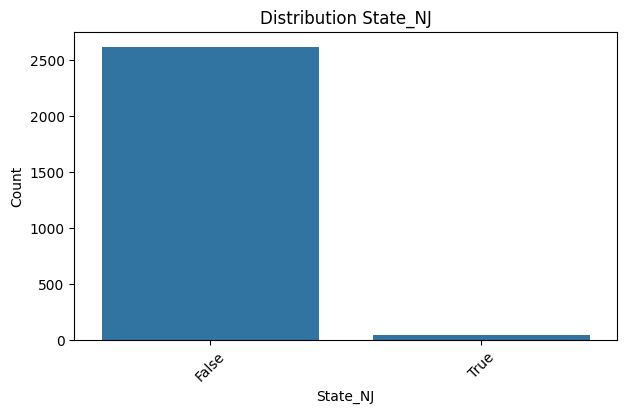

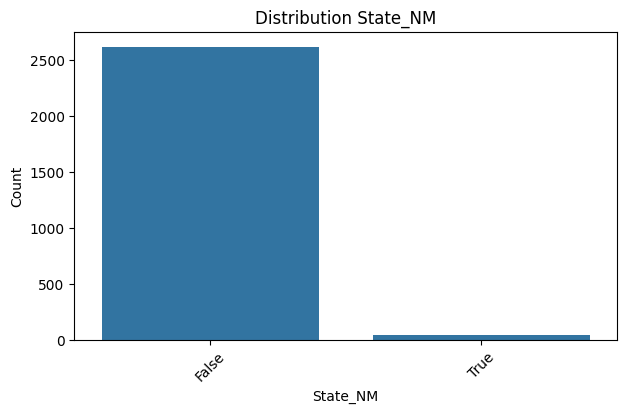

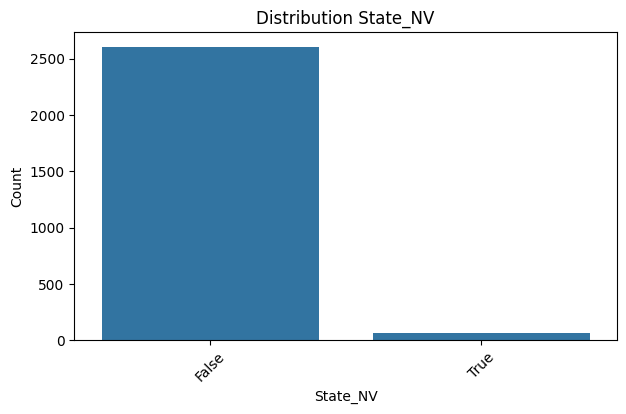

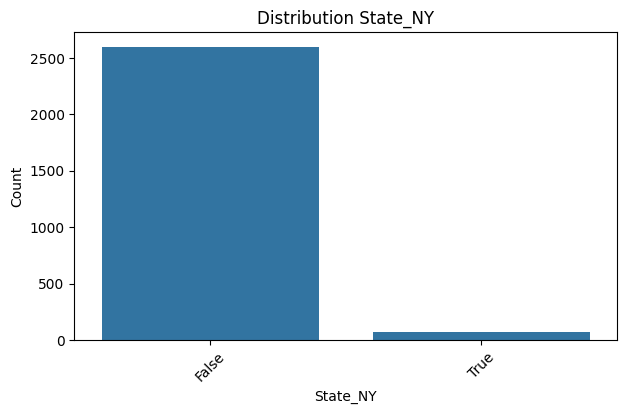

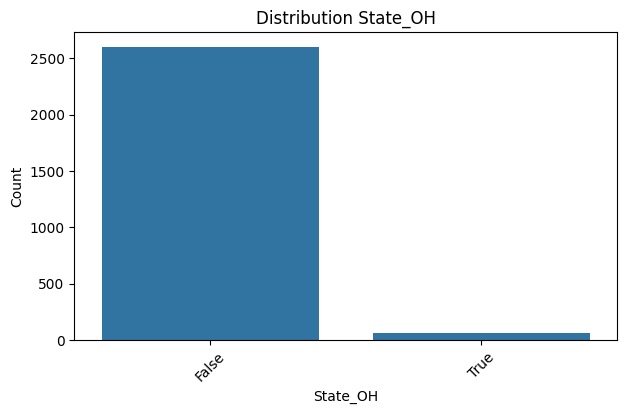

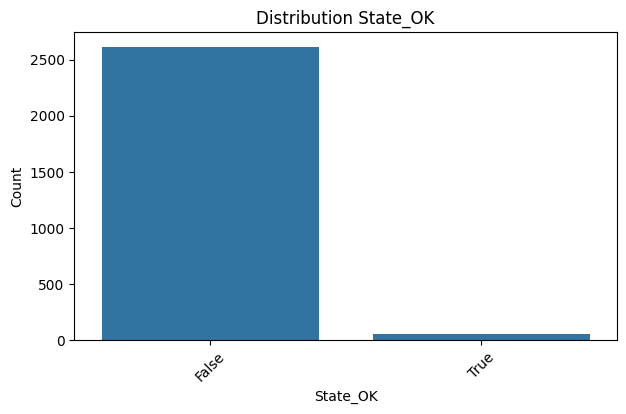

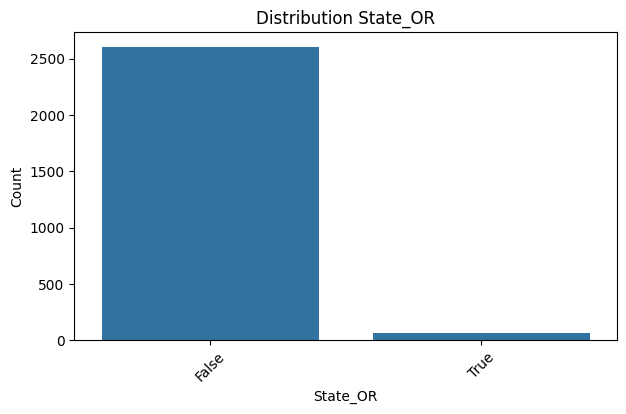

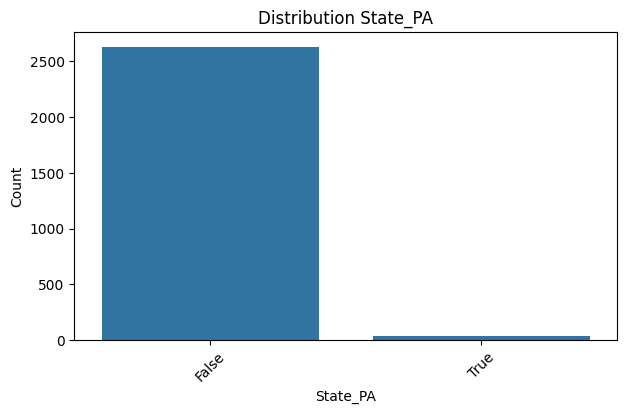

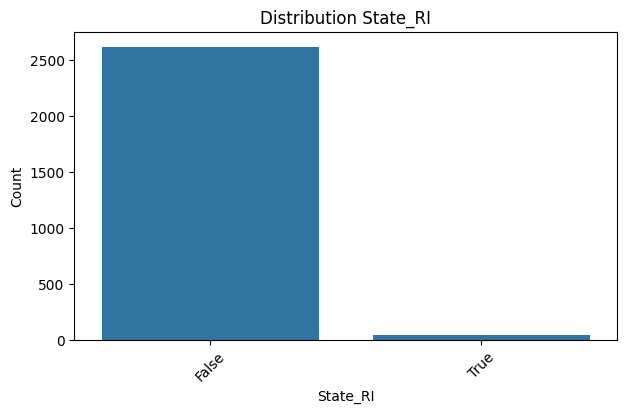

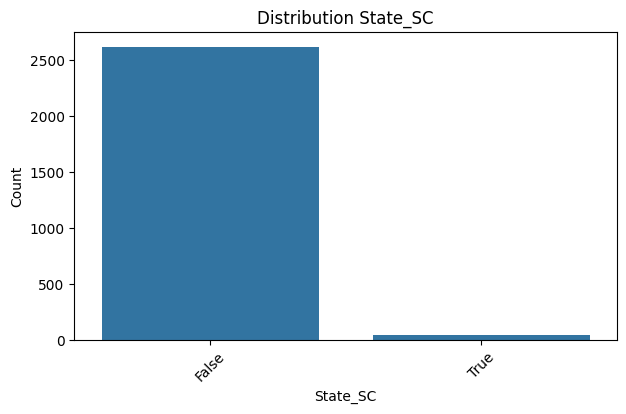

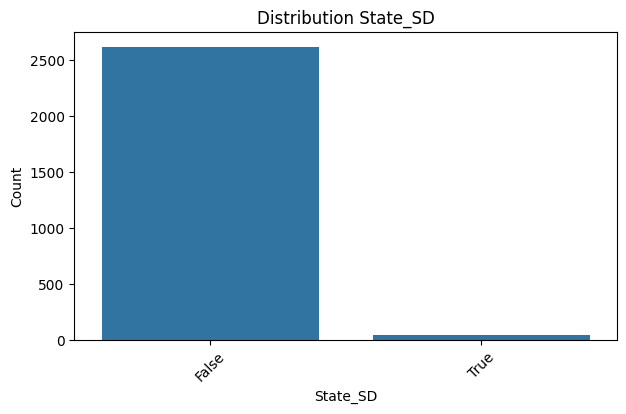

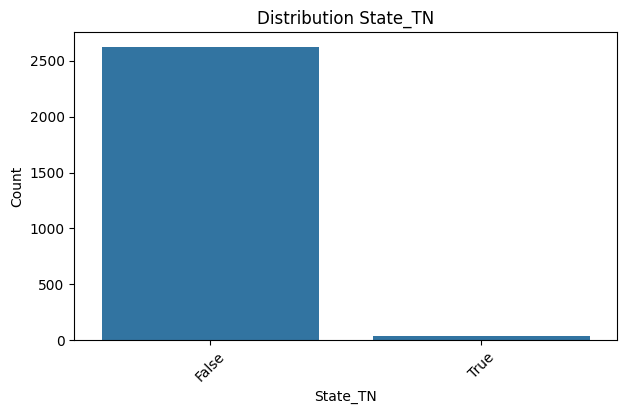

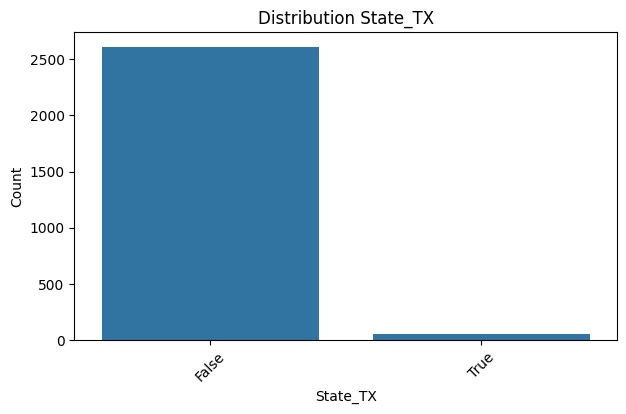

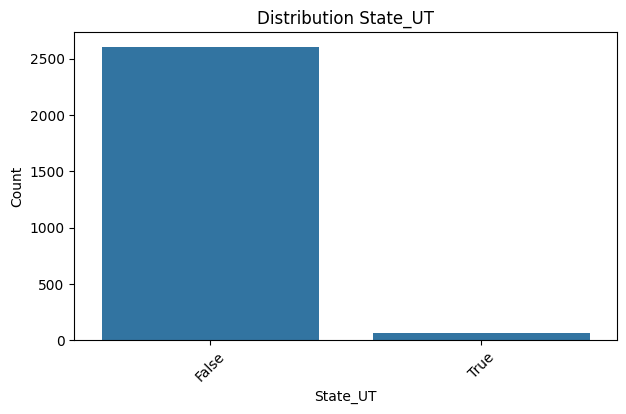

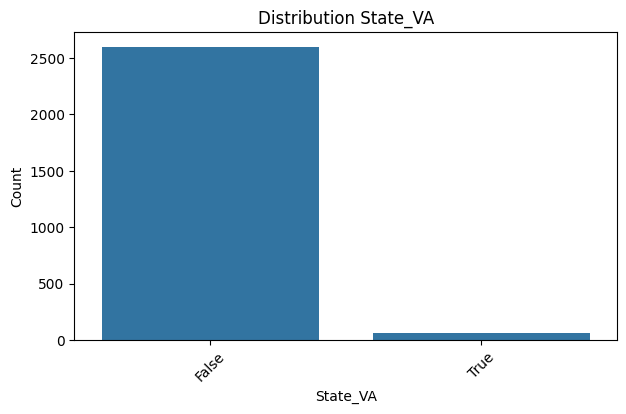

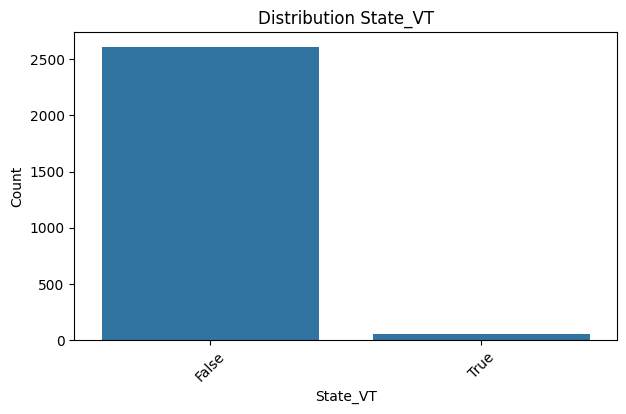

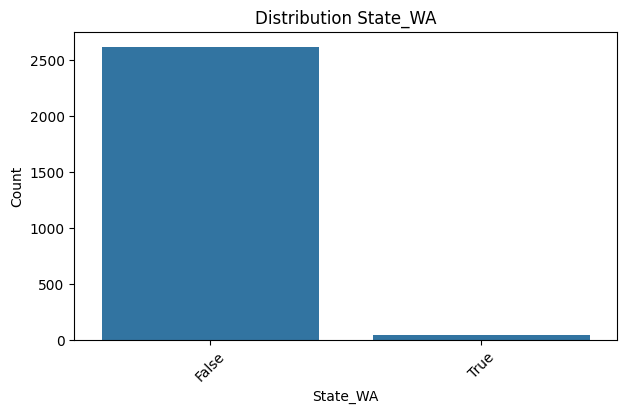

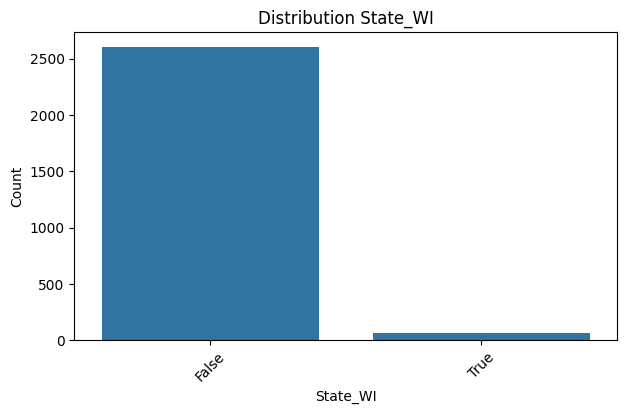

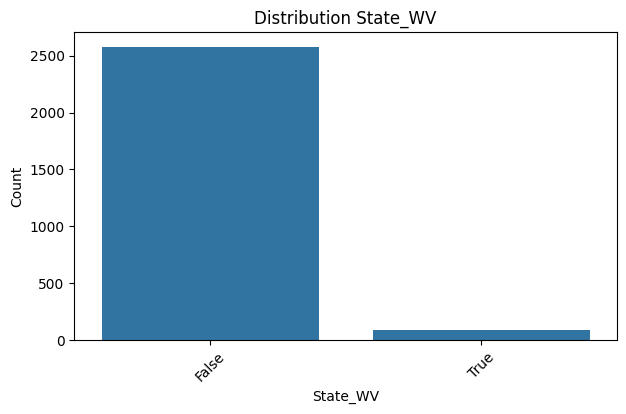

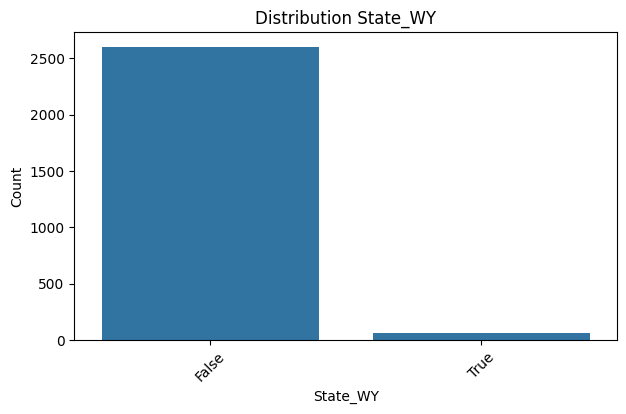

In [13]:
# Count plots for categorical features
for col in categorical_cols:
  plt.figure(figsize=(7,4))
  sns.countplot(x=col, data=df)
  plt.title(f"Distribution {col}")
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.xticks(rotation=45)
  plt.show()

## Observations
All categorical variables were encoded during preprocessing in notebook 02. Therefore, no raw categorical variables remain for direct visualization.
Encoded features will be evaluated indirectly through correlation analysis and modelling.

# 7.Correlation Analysis
This section examines relationships between numerical variables using a correlation matrix.

In [14]:
# Correlation Matrix
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
Account length,1.000000,-0.008620,0.024500,0.002448,-0.002996,0.002847,0.038862,0.002843,-0.015923,0.018552,...,0.021433,-0.032553,-0.030161,-0.002763,0.021230,0.012432,0.008645,-0.014259,-0.028746,0.019166
Area code,-0.008620,1.000000,0.047099,0.007180,-0.000584,-0.023134,-0.009629,-0.023130,0.000679,-0.018602,...,0.016323,-0.002366,-0.018258,0.011402,-0.002390,0.008722,-0.004185,-0.003704,0.023971,-0.003746
International plan,0.024500,0.047099,1.000000,0.002131,0.005858,0.049550,-0.004277,0.049555,0.026616,0.010277,...,0.000347,0.018669,0.003760,-0.009024,0.009647,-0.006642,-0.017403,-0.001478,-0.027226,0.018530
Voice mail plan,0.002448,0.007180,0.002131,1.000000,0.957159,0.013438,-0.007541,0.013439,0.019132,0.003404,...,0.009555,0.004965,-0.018451,0.008515,-0.018363,-0.015517,-0.039155,0.001283,0.003785,-0.011604
Number vmail messages,-0.002996,-0.000584,0.005858,0.957159,1.000000,0.019027,-0.009622,0.019027,0.011401,0.005131,...,0.013529,-0.006023,-0.018458,0.012765,-0.016104,-0.016241,-0.038355,0.001967,0.013126,-0.011607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
State_VT,0.012432,0.008722,-0.006642,-0.015517,-0.016241,0.009906,0.005361,0.009913,0.005416,-0.022300,...,-0.020225,-0.018473,-0.021453,-0.022428,-0.023732,1.000000,-0.020014,-0.022618,-0.027309,-0.023550
State_WA,0.008645,-0.004185,-0.017403,-0.039155,-0.038355,-0.010041,0.001427,-0.010038,0.009683,-0.028707,...,-0.018528,-0.016922,-0.019652,-0.020546,-0.021741,-0.020014,1.000000,-0.020720,-0.025017,-0.021574
State_WI,-0.014259,-0.003704,-0.001478,0.001283,0.001967,-0.010464,-0.025347,-0.010473,-0.007892,-0.007149,...,-0.020939,-0.019124,-0.022210,-0.023219,-0.024569,-0.022618,-0.020720,1.000000,-0.028272,-0.024381
State_WV,-0.028746,0.023971,-0.027226,0.003785,0.013126,-0.025461,0.038735,-0.025457,-0.052365,-0.006049,...,-0.025281,-0.023090,-0.026815,-0.028034,-0.029664,-0.027309,-0.025017,-0.028272,1.000000,-0.029436


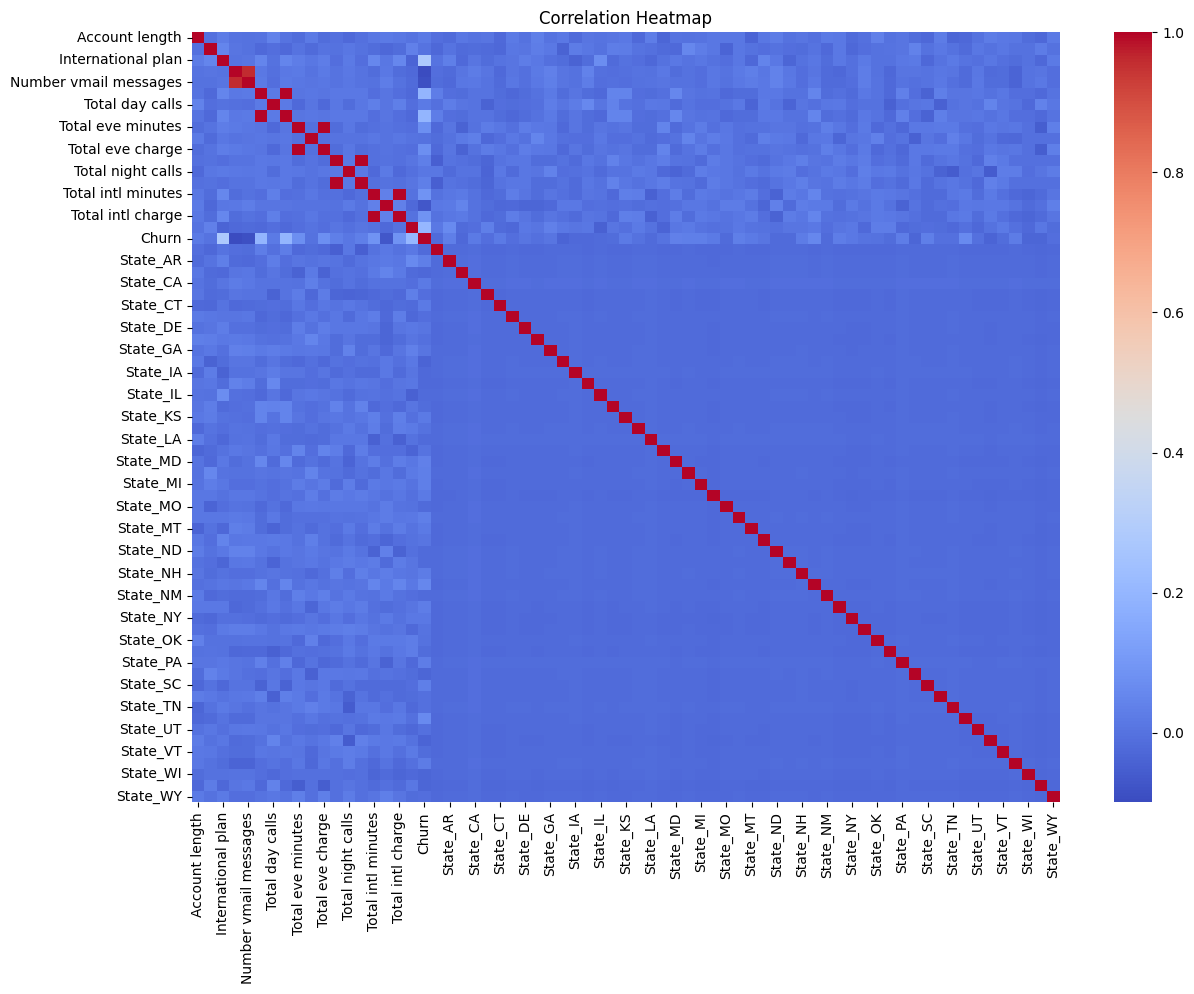

In [15]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [16]:
# Correlation with Churn
if "Churn" in corr_matrix.columns:
  churn_corr = corr_matrix["Churn"].sort_values(ascending=False)
  churn_corr

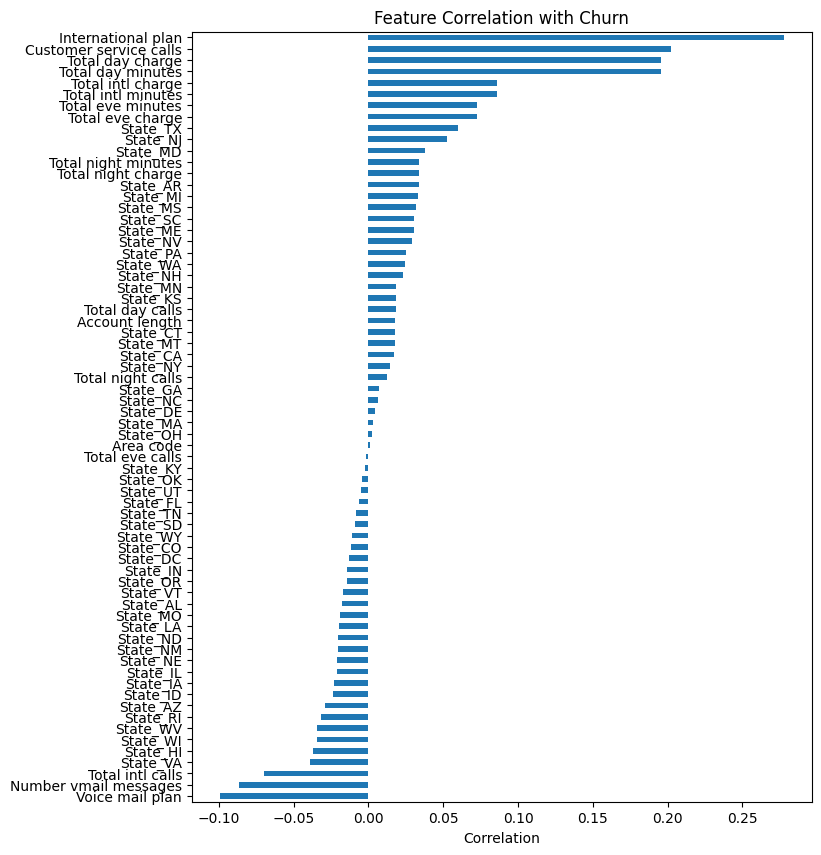

In [17]:
# Plot top correlations with Churn
if "Churn" in corr_matrix.columns:
  churn_corr.drop("Churn").sort_values().plot(kind="barh", figsize=(8, 10))
  plt.title("Feature Correlation with Churn")
  plt.xlabel("Correlation")
  plt.show()

## Observations
The correlation analysis shows that most features have relatively low to moderate correlation with the target variable ("Churn")
*   Some features exhibit stronger relationships with churn, indicating potential predictive value
*   Positive correlations suggest that higher values of a feature increase the likelihood of churn.
*   Negative correlations suggest that higher values reduce the likelihood of churn
*   No single feature dominates, indicating that churn is likely influenced by a combination of factors.

These findings will guide feature selection in the next stage.

# 8. Feature-by-Feature Insights

Based on the Exploratory Analysis, several patterns can be observed:

*   Certain usage related features show noticeable differences between churned and non churned customers
*   Customer behaviour features such as service interactions appear to play a role in churn.
*   Some variables show clearer separations between churn and non churn groups, indicating stronger predictive potential.
*   Other Features show little variation and may be less useful for modelling

Summary:
These findings provide an initial understanding of the factors influencing customer churn and will guide feature engineering and model development in the next stage.

